<a href="https://colab.research.google.com/github/AnishaP3/Reducing-Inventory-Waste-in-Grocery-Stores/blob/main/Milestone_2_Dataset_and_Problem_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
---
#<center>**Reducing Inventory Waste in Grocery Stores**<center/>     
##### <center>**Anisha Penikalapati | Kritika Rajpal | Mary Penta Reddy | Suha Fasih | Zawwar Rizvi**<center/>

---

## **<ins>Data Card</ins>**

###**`Dataset Overview:`**
- **Name:** Perishable Goods Management
- **Description:**
  - This dataset shows how product characteristics, pricing, demand, and storage conditions contribute to food spoilage.
  - 100,000 perishable product transactions
  - 10 product categories: Dairy, Meat, Seafood, Produce, Bakery, Deli, Frozen Meals, Beverages, Pharmaceuticals, and Ready-to-Eat items
  - Data from 2 years (2023-2024)
  - Includes 50 stores across 5 US regions and 20 suppliers

- **Domain:** Grocery Retail

###**`Dataset Source:`**
https://www.kaggle.com/datasets/likithagedipudi/perishable-goods-management

###**`Dataset License:`**
CC0: Public Domain

###**`Number of Rows:`**
100 000

###**`Number of Columns:`**
42

###**`Features:`**
-  **Product Information:**
    - `product_id`, `product_name`, `category`, `shelf_life_days`, `spoilage_sensitivity`, `quality_grade`
-  **Store & Supplier Information:**
    - `store_id`, `region`, `supplier_id`, `supplier_score`
-  **Date & Time:**
    - `transaction_date`, `expiration_date`, `days_remaining_at_purchase`, `day_of_week`, `is_weekend`, `month`, `days_until_expiry`
-  **Pricing & Promotions:**
    - `base_price`, `cost_price`, `is_promoted`, `markdown_applied`, `discount_pct`, `selling_price`
-  **Demand & Inventory:**
    - `initial_quantity`, `daily_demand`, `demand_variability`, `units_sold`, `units_wasted`, `waste_pct`
-  **Storage & Handling:**
    - `storage_temp`, `temp_deviation`, `temp_abuse_events`, `handling_score`, `packaging_score`, `distribution_hours`
-  **Outcome Variables:**
    - `profit`, `spoilage_risk`, `was_spoiled`, `revenue`, `waste_cost`, `profit_margin_pct`


###**`Intended Use:`**
- The dataset is intended for predicting waste risk of perishable items and building a machine learning model for food waste reduction and inventory optimization.

###**`Limitations:`**

- This dataset was synthetically generated and may not reflect real-world data
- Only includes grocery stores in the U.S.
- Data may have missing, noisy, or unrealistic values
- Some features may be redundant or irrelevant and will be removed during data cleaning and processing




## **<ins>Sample Inputs & Outputs</ins>**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [ ]:
# Load data
url = "https://drive.google.com/uc?export=download&id=1mtKaQBoUcGrpH2ppFvM6JPbYfzYeu_4E"
perishable = pd.read_csv(url)

#### **Sample Inputs**

In [ ]:
# First 5 data points of the dataset
perishable.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


The first five rows of the dataset displays a summary of the input features used for the prediction of food spoiling. Each row represents one perishable item, including product details, such as category and shelf‑life, store and supplier information, pricing, demand patterns, storage conditions, and handling scores. These inputs form the feature set that the machine‑learning model will use to learn patterns related to spoilage and waste.

#### **Sample Outputs**

In [ ]:
# Shows amount of food that is spoiled
perishable['was_spoiled'].value_counts()


,count
was_spoiled,
0,80558
1,19442


The target variable for this project is 'was_spoiled', which indicates whether the item is spoiled (1) or did not spoil (0). This output represents the binary classification that the model will predict.

## **<ins>Initial EDA</ins>**

In [ ]:
# Checking the shape of the dataset
df=perishable.copy()
df.shape

(100000, 42)

In [ ]:
# Using df.describe(), we examined:
# Pricing ranges, Demand patterns, Storage conditions, Waste metrics
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,67.169300,56.114940,3.127054,1.597402,36.408563,20.05853,254.851800,0.685802,3.001080,...,34.356048,202.835650,52.016150,22.591979,5911.547597,1632.244932,797.837098,13.394057,8.207760,0.148980
std,28867.657797,140.550322,118.160892,9.503199,1.206793,87.424777,48.89381,141.686286,0.215392,2.000745,...,85.381541,138.942464,79.279844,28.717231,19277.611250,8275.432747,11331.288655,46.246729,1.397525,0.356071
min,1.000000,1.000000,0.000000,-27.700000,0.000000,1.000000,0.41000,10.000000,0.300000,0.000000,...,0.260000,0.000000,0.000000,0.000000,0.000000,0.000000,-169495.000000,-1798.800000,6.000000,0.000000
25%,25000.750000,5.000000,4.000000,1.100000,0.600000,6.270000,3.36000,132.000000,0.500000,1.000000,...,5.320000,85.000000,0.000000,0.000000,542.880000,0.000000,-48.460000,0.000000,7.000000,0.000000
50%,50000.500000,9.000000,8.000000,4.000000,1.400000,10.220000,5.58000,255.000000,0.750000,3.000000,...,8.800000,193.000000,15.000000,12.400000,1450.420000,62.505000,276.700000,26.300000,9.000000,0.000000
75%,75000.250000,24.000000,20.000000,6.600000,2.300000,17.010000,9.50000,377.000000,0.900000,5.000000,...,15.450000,309.000000,80.000000,30.800000,3170.720000,431.660000,992.677500,41.100000,9.000000,0.000000
max,100000.000000,730.000000,723.000000,27.700000,9.000000,499.980000,346.61000,500.000000,0.950000,6.000000,...,499.980000,500.000000,500.000000,100.000000,246243.640000,169495.000000,136195.210000,60.300000,10.000000,1.000000


- All values were reasonable, and there weren’t any extreme outliers or unrealistic values detected.

<Axes: >

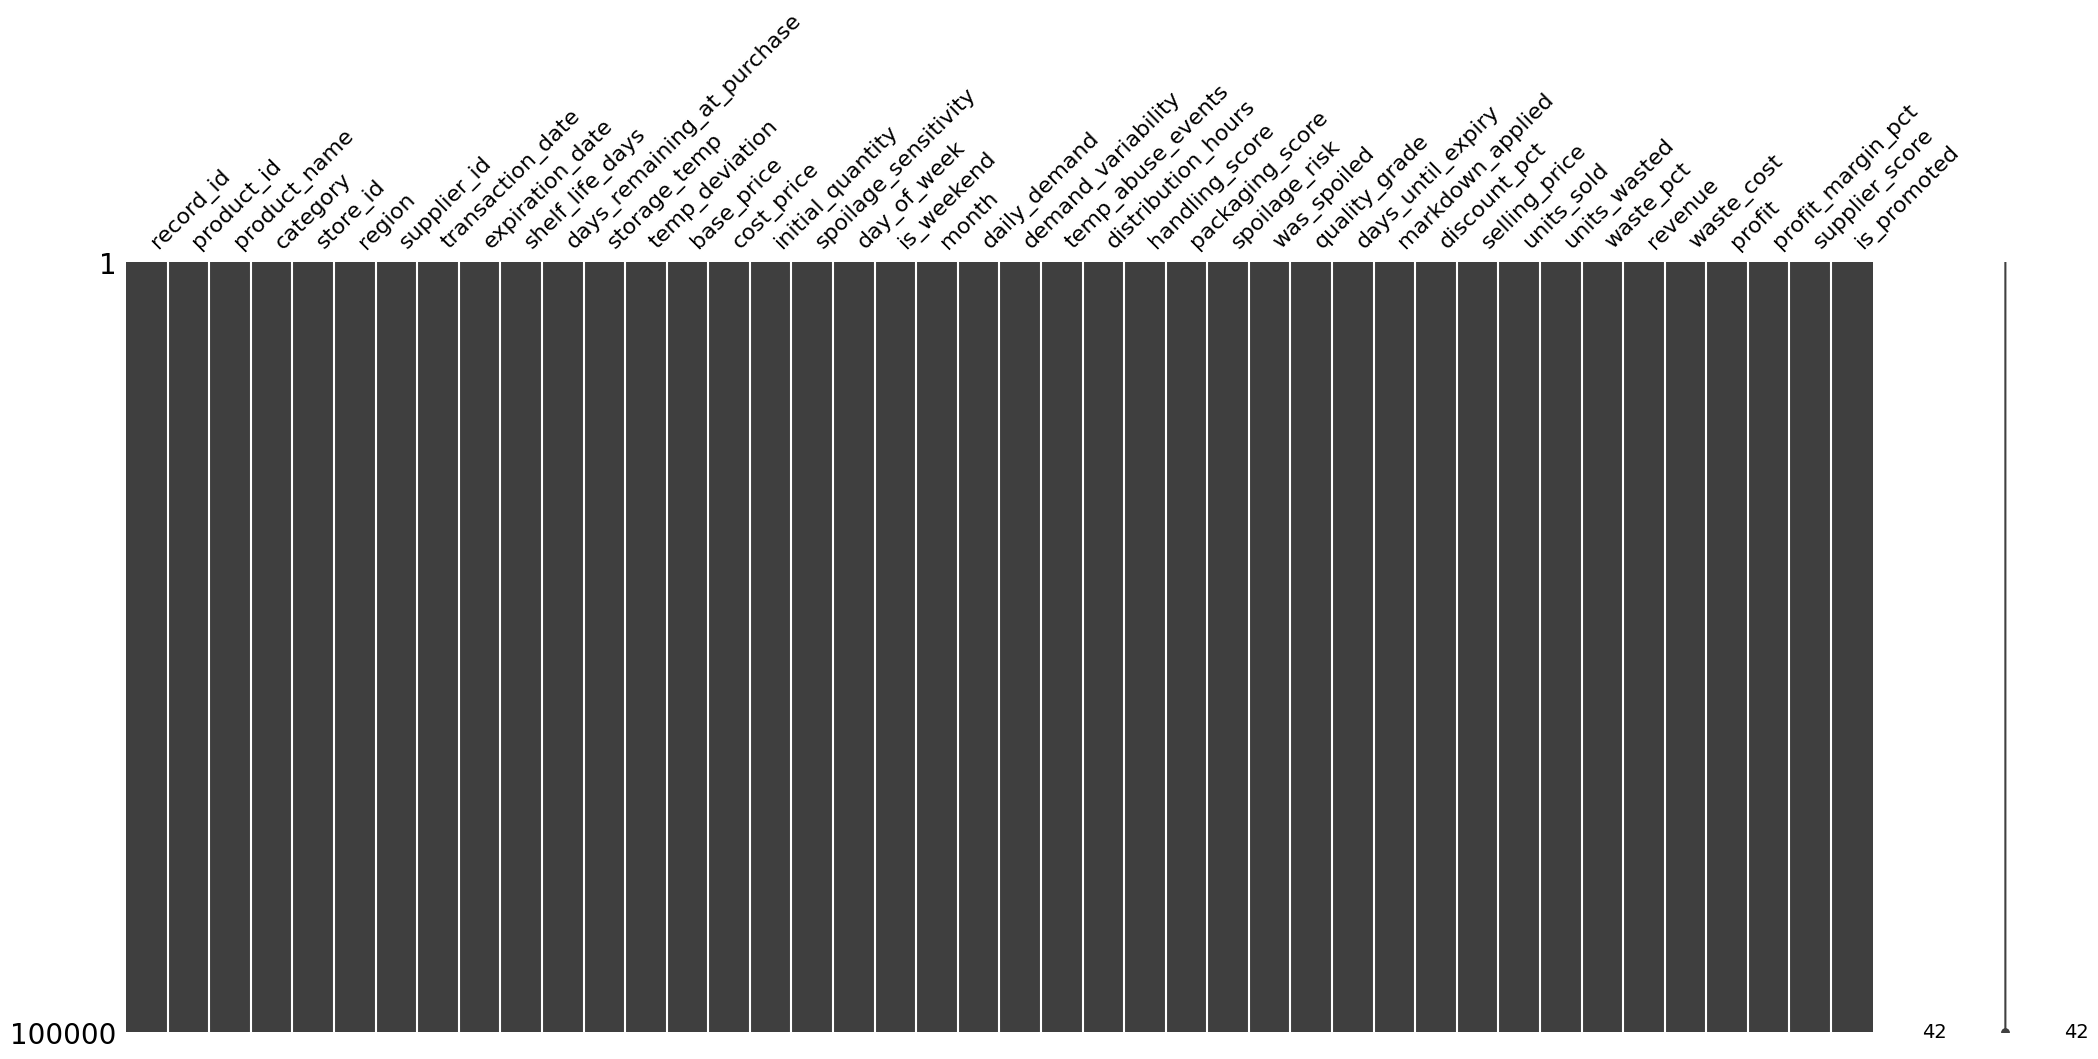

In [ ]:
# Checked to see if there were any missing values.
import missingno
missingno.matrix(df)

- There were no missing values in any of the 42 columns and 100,000 rows.
- The dataset is complete, so there is no need to balance the data.

In [ ]:
# The number of duplicate values
df.duplicated().sum()


np.int64(0)

- There were no duplicate values in the dataset.
- There was no need to remove any duplicate or redundant values for data cleaning.

In [ ]:
# Printing the data types of the features in the dataset
object_cols = (df.dtypes == "object").sum()
int_cols = (df.dtypes == "int64").sum()
float_cols = (df.dtypes == "float64").sum()
print("Number of Columns with Types: \nObject:", object_cols, "\nInt:   ", int_cols, "\nFloat: ", float_cols)


Number of Columns with Types: 
Object: 9 
Int:    18 
Float:  15


In [ ]:
# Understanding the Data Types and Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   100000 non-null  int64  
 1   product_id                  100000 non-null  object 
 2   product_name                100000 non-null  object 
 3   category                    100000 non-null  object 
 4   store_id                    100000 non-null  object 
 5   region                      100000 non-null  object 
 6   supplier_id                 100000 non-null  object 
 7   transaction_date            100000 non-null  object 
 8   expiration_date             100000 non-null  object 
 9   shelf_life_days             100000 non-null  int64  
 10  days_remaining_at_purchase  100000 non-null  int64  
 11  storage_temp                100000 non-null  float64
 12  temp_deviation              100000 non-null  float64
 13  base_price     

- All numeric columns were stored as integers or floats.
- Date columns (transaction_date, expiration_date) were initially strings and required conversion to datetime format
- Categorical columns such as category, region, and quality_grade were stored as objects.
- No unexpected or corrupted data types were found.


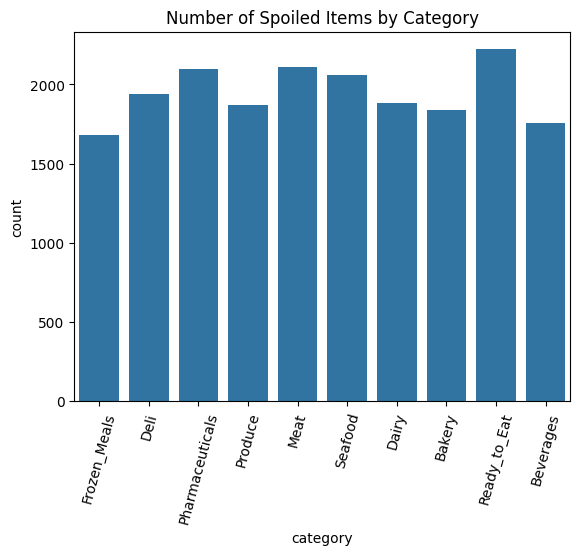

In [ ]:
# Plots the number of items spolied for each category
sns.countplot(x='category', data=df[df['was_spoiled'] == 1])
plt.title('Number of Spoiled Items by Category')
plt.xticks(rotation=75)
plt.show()


- Pharmaceuticals, meat, seafood, and ready-to-eat items have higher spoilage rates compared to other categories.
- This helps identify which categories contribute to the most inventory waste and which categories to focus on to reduce waste.


array([[<Axes: title={'center': 'record_id'}>,
        <Axes: title={'center': 'shelf_life_days'}>,
        <Axes: title={'center': 'days_remaining_at_purchase'}>,
        <Axes: title={'center': 'storage_temp'}>,
        <Axes: title={'center': 'temp_deviation'}>,
        <Axes: title={'center': 'base_price'}>],
       [<Axes: title={'center': 'cost_price'}>,
        <Axes: title={'center': 'initial_quantity'}>,
        <Axes: title={'center': 'spoilage_sensitivity'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'is_weekend'}>,
        <Axes: title={'center': 'month'}>],
       [<Axes: title={'center': 'daily_demand'}>,
        <Axes: title={'center': 'demand_variability'}>,
        <Axes: title={'center': 'temp_abuse_events'}>,
        <Axes: title={'center': 'distribution_hours'}>,
        <Axes: title={'center': 'handling_score'}>,
        <Axes: title={'center': 'packaging_score'}>],
       [<Axes: title={'center': 'spoilage_risk'}>,
        <A

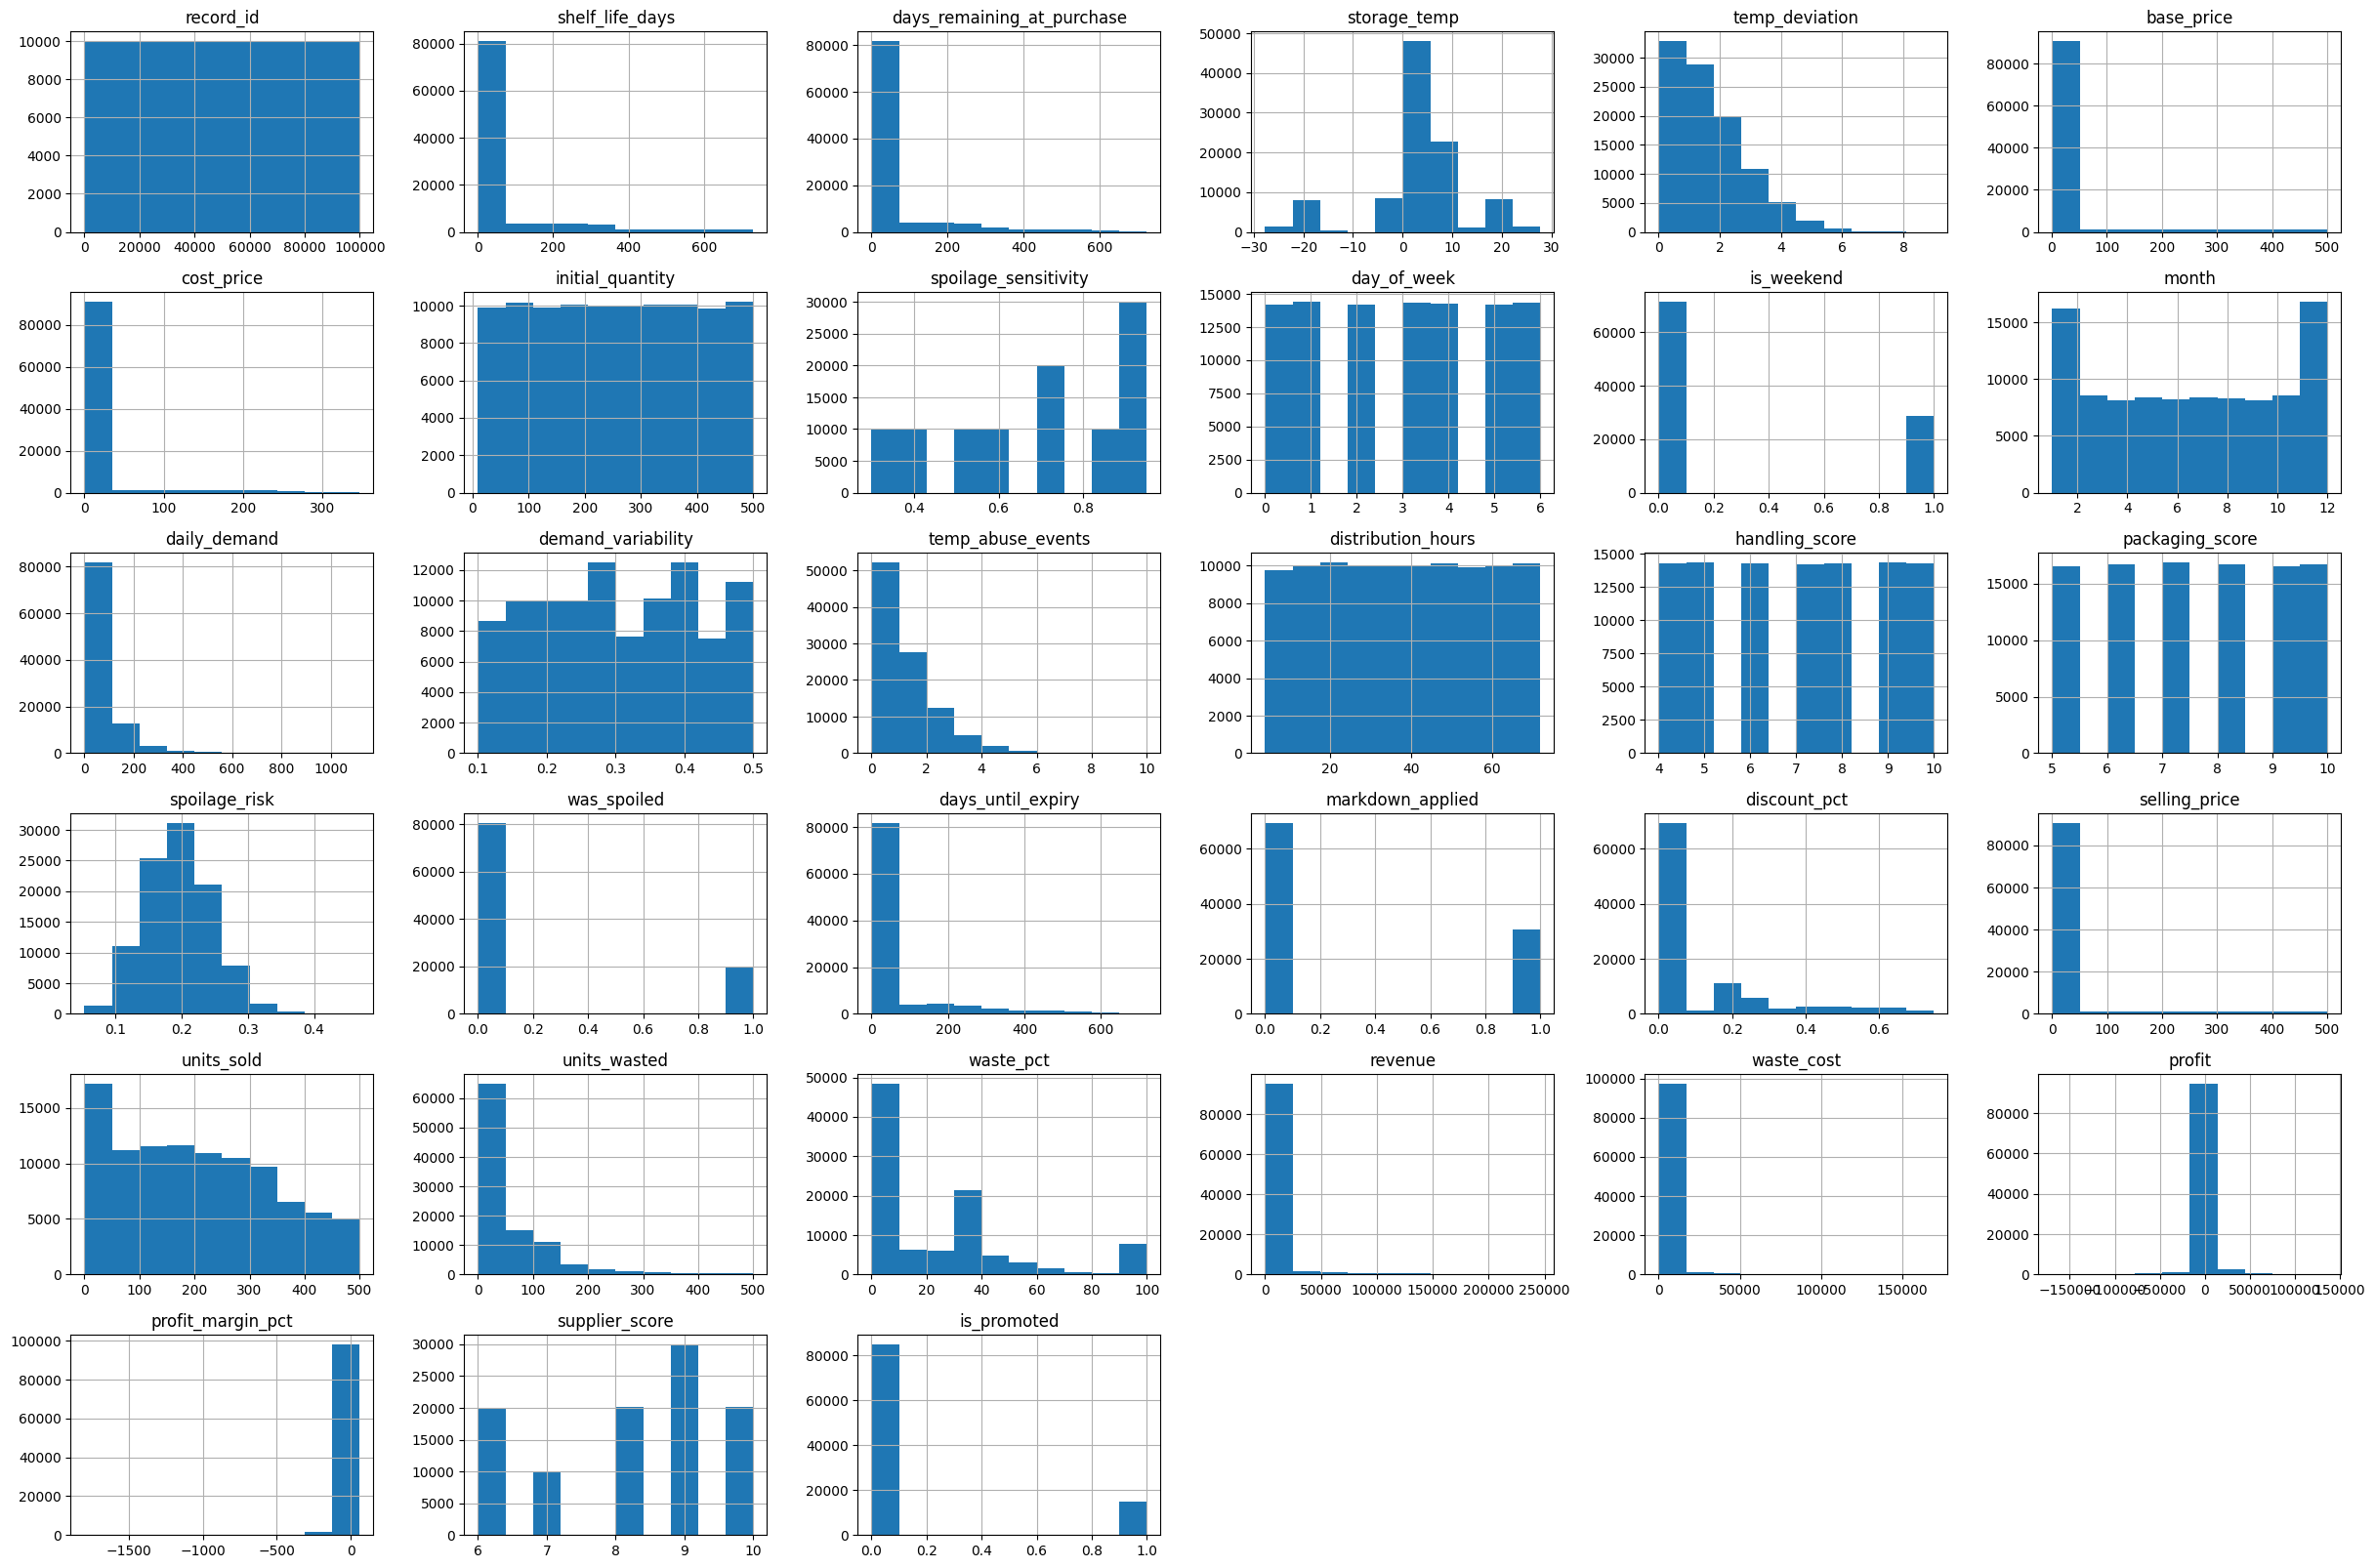

In [ ]:
# Histogram plots of each feature were generated to understand the dataset
df.hist(figsize=(30,20))


The distribution of daily demand, shelf life days, and profit is closer to the left side, with there being lower daily demand, shelf life days, and profit.

#### **Initial EDA Summary**

The dataset is quite large with 100,000 rows and 42 columns, which will give us plenty of data to work with for our project. Since it's a synthetic dataset, there are no duplicates or any missing values at all. This makes data cleaning and preprocessing easier, but it could point to the fact that this data is unrealistic and may not reflect real-life results.

The EDA shows that spoilage rates are higher for certain categories compared to others such as pharmaceuticals, meat, seafood, and ready-to-eat items. This shows that product type, handling and storage conditions can contribute to predicting spoilage.

## **<ins>Dataset Filtering and Cleaning</ins>**

In [ ]:
# Removed ID Columns & Unnecessary Date Columns
df = df.drop(columns=['record_id', 'product_id', 'store_id', 'supplier_id', 'day_of_week', 'is_weekend', 'month'])

These columns do not contribute to prediction and were not needed for modeling.

In [ ]:
df

,product_name,category,region,transaction_date,expiration_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,Donuts,Bakery,West,2024-09-25,2024-09-29,4,4,21.0,1.0,2.60,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,Sausages,Meat,Southwest,2023-04-14,2023-04-21,9,7,0.7,0.3,8.25,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,Bagels,Bakery,Midwest,2024-10-25,2024-10-27,2,2,21.3,1.3,4.12,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,Vaccines,Pharmaceuticals,Midwest,2023-11-29,2024-02-17,87,80,8.0,3.0,209.56,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,Fresh Pasta,Ready_to_Eat,West,2023-08-06,2023-08-09,4,3,3.5,0.5,6.86,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Dips,Deli,Southwest,2024-12-22,2024-12-27,5,5,3.5,0.5,12.10,...,12.10,149,0,0.0,1802.90,0.00,1063.86,59.0,10,0
99996,Frozen Dinners,Frozen_Meals,Midwest,2023-11-28,2024-06-06,204,191,-21.1,1.1,13.60,...,13.60,0,212,100.0,0.00,1392.84,-1392.84,0.0,8,0
99997,Chicken,Meat,Southwest,2023-06-15,2023-06-21,9,6,1.8,0.8,12.28,...,12.28,264,208,44.1,3241.92,1312.48,263.60,8.1,10,1
99998,Eye Drops,Pharmaceuticals,West,2024-12-14,2026-03-03,581,444,4.6,0.4,320.12,...,320.12,0,251,100.0,0.00,51919.35,-51919.35,0.0,6,0


In [ ]:
# Changing the transaction dates and expiration dates from strings to DateTime

from datetime import datetime
date_format = "%Y-%m-%d"
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['expiration_date'] = pd.to_datetime(df['expiration_date'])
df.dtypes

,0
product_name,object
category,object
region,object
transaction_date,datetime64[ns]
expiration_date,datetime64[ns]
shelf_life_days,int64
days_remaining_at_purchase,int64
storage_temp,float64
temp_deviation,float64
base_price,float64


- These columns were converted from strings to datetime format so that it can be easier to sort and split the data into train/validate/test sections based on time.

In [ ]:
# Converting is_promoted type to boolean so that it is easier to read
df['is_promoted'] = df['is_promoted'].astype('bool')
df

,product_name,category,region,transaction_date,expiration_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,Donuts,Bakery,West,2024-09-25,2024-09-29,4,4,21.0,1.0,2.60,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,False
1,Sausages,Meat,Southwest,2023-04-14,2023-04-21,9,7,0.7,0.3,8.25,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,False
2,Bagels,Bakery,Midwest,2024-10-25,2024-10-27,2,2,21.3,1.3,4.12,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,False
3,Vaccines,Pharmaceuticals,Midwest,2023-11-29,2024-02-17,87,80,8.0,3.0,209.56,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,False
4,Fresh Pasta,Ready_to_Eat,West,2023-08-06,2023-08-09,4,3,3.5,0.5,6.86,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Dips,Deli,Southwest,2024-12-22,2024-12-27,5,5,3.5,0.5,12.10,...,12.10,149,0,0.0,1802.90,0.00,1063.86,59.0,10,False
99996,Frozen Dinners,Frozen_Meals,Midwest,2023-11-28,2024-06-06,204,191,-21.1,1.1,13.60,...,13.60,0,212,100.0,0.00,1392.84,-1392.84,0.0,8,False
99997,Chicken,Meat,Southwest,2023-06-15,2023-06-21,9,6,1.8,0.8,12.28,...,12.28,264,208,44.1,3241.92,1312.48,263.60,8.1,10,True
99998,Eye Drops,Pharmaceuticals,West,2024-12-14,2026-03-03,581,444,4.6,0.4,320.12,...,320.12,0,251,100.0,0.00,51919.35,-51919.35,0.0,6,False


## **<ins>Dataset Pre-processing</ins>**

In [ ]:
# Removed Columns that could Leak Data and reveal information that would not be available before spoilage occurs
df = df.drop(columns=['units_wasted', 'waste_pct', 'waste_cost', 'profit', 'revenue', 'profit_margin_pct', 'spoilage_risk', 'units_sold', 'selling_price', 'markdown_applied', 'discount_pct','days_until_expiry', 'expiration_date'])
df

,product_name,category,region,transaction_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,...,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,was_spoiled,quality_grade,supplier_score,is_promoted
0,Donuts,Bakery,West,2024-09-25,4,4,21.0,1.0,2.60,1.22,...,54,0.35,0,41.5,9,10,0,A,9,False
1,Sausages,Meat,Southwest,2023-04-14,9,7,0.7,0.3,8.25,4.18,...,55,0.35,0,38.7,8,8,0,A,6,False
2,Bagels,Bakery,Midwest,2024-10-25,2,2,21.3,1.3,4.12,2.12,...,331,0.35,0,54.1,4,8,0,B,9,False
3,Vaccines,Pharmaceuticals,Midwest,2023-11-29,87,80,8.0,3.0,209.56,87.99,...,7,0.38,0,70.1,5,9,0,B,6,False
4,Fresh Pasta,Ready_to_Eat,West,2023-08-06,4,3,3.5,0.5,6.86,3.03,...,169,0.25,0,64.9,5,6,0,C,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Dips,Deli,Southwest,2024-12-22,5,5,3.5,0.5,12.10,4.96,...,53,0.18,1,34.3,10,10,0,A,10,False
99996,Frozen Dinners,Frozen_Meals,Midwest,2023-11-28,204,191,-21.1,1.1,13.60,6.57,...,0,0.46,0,55.8,6,7,1,B,8,False
99997,Chicken,Meat,Southwest,2023-06-15,9,6,1.8,0.8,12.28,6.31,...,65,0.21,0,52.3,6,7,0,B,10,True
99998,Eye Drops,Pharmaceuticals,West,2024-12-14,581,444,4.6,0.4,320.12,206.85,...,0,0.29,0,11.4,8,9,0,A,6,False


In [ ]:
# Removed irrelevant column that does not help predict spoilage
df = df.drop(columns=['distribution_hours'])
df

,product_name,category,region,transaction_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,...,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,handling_score,packaging_score,was_spoiled,quality_grade,supplier_score,is_promoted
0,Donuts,Bakery,West,2024-09-25,4,4,21.0,1.0,2.60,1.22,...,0.50,54,0.35,0,9,10,0,A,9,False
1,Sausages,Meat,Southwest,2023-04-14,9,7,0.7,0.3,8.25,4.18,...,0.90,55,0.35,0,8,8,0,A,6,False
2,Bagels,Bakery,Midwest,2024-10-25,2,2,21.3,1.3,4.12,2.12,...,0.50,331,0.35,0,4,8,0,B,9,False
3,Vaccines,Pharmaceuticals,Midwest,2023-11-29,87,80,8.0,3.0,209.56,87.99,...,0.85,7,0.38,0,5,9,0,B,6,False
4,Fresh Pasta,Ready_to_Eat,West,2023-08-06,4,3,3.5,0.5,6.86,3.03,...,0.90,169,0.25,0,5,6,0,C,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Dips,Deli,Southwest,2024-12-22,5,5,3.5,0.5,12.10,4.96,...,0.75,53,0.18,1,10,10,0,A,10,False
99996,Frozen Dinners,Frozen_Meals,Midwest,2023-11-28,204,191,-21.1,1.1,13.60,6.57,...,0.30,0,0.46,0,6,7,1,B,8,False
99997,Chicken,Meat,Southwest,2023-06-15,9,6,1.8,0.8,12.28,6.31,...,0.90,65,0.21,0,6,7,0,B,10,True
99998,Eye Drops,Pharmaceuticals,West,2024-12-14,581,444,4.6,0.4,320.12,206.85,...,0.85,0,0.29,0,8,9,0,A,6,False


#### **Time-Based Train/Validation/Test Split**
- **Training set (70%):** earliest transactions
- **Validation set (15%):** middle portion
- **Test set (15%):** most recent transactions


In [ ]:
# Sort data by transaction dates to prepare for the split
df_transactions = df.sort_values(by='transaction_date')

# Set cutoffs for training and test sets
# earliest 70% of rows for training
# middle 15% for validation
# most recent 15% for testing
train_cutoff = int(len(df_transactions) * 0.7)
val_cutoff = int(len(df_transactions) * 0.85)

# Split the data into Training, Validation, and Test sets using the cutoffs
df_train = df_transactions.iloc[:train_cutoff]
df_val = df_transactions.iloc[train_cutoff:val_cutoff]
df_test = df_transactions.iloc[val_cutoff:]

# Check the sizes of the new sets to ensure none of the rows are missing or duplicated
print("Original set shape:  ", df.shape)
print("Training set shape:  ", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:      ", df_test.shape)

Original set shape:   (100000, 21)
Training set shape:   (70000, 21)
Validation set shape: (15000, 21)
Test set shape:       (15000, 21)


We split the data based on time to ensure the model learns from past information to help predict future spoilage.

## **<ins>Target/Tasks</ins>**

#### **Target**





The target variable for our project will be `was_spoiled`, which indicates whether a perishable product is spoiled. The target is represented as a binary variable where:

- `0` = product was not spoiled
- `1` = product was spoiled





#### **Task**

This project is a **binary classification** task. We will use product, store, demand, pricing, and storage-related features to predict whether a product is likely to become spoiled. Our end goal is to identify products at higher risk of spoilage so that grocery stores can potentially prioritize appropriate waste-reduction actions.

## **<ins>Risks</ins>**

- The dataset was synthetically generated, so it may not reflect real-world data
- Data may have missing, noisy, or unrealistic values
- Some features may be redundant or irrelevant
- With 42 features, some may be correlated or very similar, which could lead to overfitting



## **<ins>Train/Validation/Test Strategies</ins>**

The dataset will be divided into three parts: training, validation, and testing. The training set will be used to learn patterns and relationships between different features, and it will contain the early portion of the dataset. It will be used to build a foundation for the model. The validation set will be used to tune model hyperparameters and adjust model settings. It will help detect overfitting early by comparing the models and improve generalization. This set will contain a later portion of the dataset. Finally, the testing set will contain the most recent portion and will be used to evaluate the performance of the final model after all the training and validation are complete. It will help confirm the accuracy of the model.


Since our goal is to predict how likely a food item is to spoil so that the store can identify waste-risk items earlier and make better inventory decisions, we will split the data based on time rather than randomly splitting it. This will make the performance of the machine learning model more realistic, as it will be trained on past data and tested on later data. Also, we will make sure the model uses only relevant information to make predictions. This will give us a more realistic estimate of how the model could perform in a real grocery store.


## <ins>**Primary Metric**</ins>

#### **Primary Metric: Macro F1-Score**

The primary evaluation metric for this project is Macro F1-Score.

F1-score is a single number that combines two things a classifier can get right or wrong:

**Precision:** How many transactions actually spoiled out of all the transactions the model flagged as spoiled?

**Recall:** Of all the transactions that actually spoiled, how many did the model catch?

F1 is the harmonic mean of those two. It is high only when both precision and recall are high
A model cannot cheat by being good at one and bad at the other. In binary classification, there are two classes (0 = not spoiled, 1 = spoiled), so we can compute an F1 score for each class separately. Macro F1 is the simple average of the two class F1 scores, treating both classes as equally important.



#### **Why this metric and not accuracy**


The target is imbalanced. From the EDA:

- Class 0 (not spoiled): 80,558 rows — **80.56%**
- Class 1 (spoiled): 19,442 rows — **19.44%**
- Imbalance ratio: **4.14 : 1**

Since the majority class dominates, accuracy is misleading. When the model always predicts the majority class ("not spoiled"), it has an 80.56% accuracy rate, but it fails to identify any spoilage cases, making it useless for the project goal. The majority-class baseline scores 0.8056 accuracy, but only 0.4462 Macro F1 and 0.0000 recall on spoilage. Accuracy is therefore rejected as the primary metric. Macro F1 is chosen instead because it forces the model to perform well on the minority (spoiled) class, the exact class the project cares about.



#### **Why the metric matches the real objective**


The project's goal is to help grocery stores identify products at high risk of spoilage before the spoilage occurs, so they can act (markdown, relocate, prioritize sale, adjust storage). Both types of classification errors have consequences:

- **False negative:** This is when the model says that the item "won't spoil," but it does. This results in customers buying spoiled products, causing health risks, returns, and brand damage.
- **False positive:** This is when the model says that the item "will spoil," but it doesn't. This results in unnecessary markdown or discard, wasting edible food and losing profits.


Since both types of misclassification are important, a metric that balances precision and recall works best for this model. This is why Macro F1 will be used to avoid these consequences.




#### **Secondary metrics**


The following will also be used as secondary metrics:

- **Recall:** How many spoilage events were caught?
- **Precision:** How many flagged items actually spoiled?
- **PR-AUC** (Threshold-independent comparison): preferred over ROC-AUC for class imbalance. No-skill baseline = 0.1944 (the spoilage rate).
- **Confusion matrix:** For error analysis in Milestone 5



#### **Baselines to Beat**


For a minimum benchmark, the model must outperform the majority class baseline:

| Metric | Majority-class baseline |
|---|---|
| Accuracy | 0.8056 |
| Macro F1 | 0.4462 |
| Recall (spoiled = 1) | 0.0000 |
| PR-AUC | 0.1944 |



#### **Success threshold**
The model will be considered useful if:

- **Macro F1 > 0.65**, AND
- **Recall (spoiled) > 0.70**, AND
- **PR-AUC > 0.35**, AND

These values serve as the minimum benchmark. The model that will be trained must outperform these baseline scores.

In [ ]:
# Comparing items by spoiled and not spoiled by their spoilage risk
print(perishable.groupby('was_spoiled')['spoilage_risk'].describe())

               count      mean       std    min    25%    50%    75%    max
was_spoiled                                                                
0            80558.0  0.191908  0.050016  0.053  0.156  0.190  0.225  0.460
1            19442.0  0.208622  0.050567  0.061  0.173  0.208  0.241  0.469


In [ ]:
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             accuracy_score)
import numpy as np

# Showing the ratios of spoiled food vs unspoiled food (class balance)
counts = perishable['was_spoiled'].value_counts().sort_index()
props = perishable['was_spoiled'].value_counts(normalize=True).sort_index()

# Printing the class balance
print("Class counts:")
for c in counts.index:
    print(f"  was_spoiled = {c}: {counts[c]:,} ({props[c]:.4f})")
print(f"\nImbalance ratio (0:1) = {counts[0] / counts[1]:.2f} : 1")

# shows the imbalance of the classes
y_true = perishable['was_spoiled']
y_pred_majority = np.zeros_like(y_true)

# Majority-class baseline - predicts was spoiled for all items
print("\n--- Majority-class baseline (predict 0 for all) ---")
print(f"Accuracy:              {accuracy_score(y_true, y_pred_majority):.4f}")
print(f"Macro F1:              {f1_score(y_true, y_pred_majority, average='macro'):.4f}")
print(f"F1 (spoiled=1):        {f1_score(y_true, y_pred_majority, pos_label=1, zero_division=0):.4f}")
print(f"Recall (spoiled=1):    {recall_score(y_true, y_pred_majority, pos_label=1, zero_division=0):.4f}")
print(f"Precision (spoiled=1): {precision_score(y_true, y_pred_majority, pos_label=1, zero_division=0):.4f}")

# Compute the no‑skill PR‑AUC baseline (spoilage rate)
print(f"\nNo-skill PR-AUC (baseline) = {props[1]:.4f}")

Class counts:
  was_spoiled = 0: 80,558 (0.8056)
  was_spoiled = 1: 19,442 (0.1944)

Imbalance ratio (0:1) = 4.14 : 1

--- Majority-class baseline (predict 0 for all) ---
Accuracy:              0.8056
Macro F1:              0.4462
F1 (spoiled=1):        0.0000
Recall (spoiled=1):    0.0000
Precision (spoiled=1): 0.0000

No-skill PR-AUC (baseline) = 0.1944


## **<ins>Feasibility & Compute Plan</ins>**

This project is feasible within the available time and computing resources. The dataset contains 100,000 observations and 42 variables, providing enough data to train and evaluate classification models while remaining manageable for our project. We will use only the necessary features, so the reduction of features will improve efficiency and reduce noise.


We will use Python with libraries such as pandas, matplotlib, seaborn, and NumPy for data processing, visualisation, model training, and evaluation. We can train the planned models on a standard CPU, so specialised hardware or GPU computing is not expected to be used.


To keep the experiments reproducible, we will record the data split, preprocessing steps, model settings, and experiment results. If model tuning requires more computation than expected, we will reduce the number of parameter combinations or use a smaller search space while keeping the model comparisons consistent.
